![Imgur](https://i.imgur.com/acSOZRh.png)

# Laboratorio n° 1. Parte B: Entrenamiento de Redes Neuronales

**Asignatura:** Redes Neuronales Profundas
**Bloque:** 1 — Fundamentos de Deep Learning

---

## Introducción

En el Laboratorio 1A aprendiste a operar con tensores. Ahora vas a usar esas herramientas para algo concreto: **entrenar redes neuronales**.

En este trabajo vas a:

1. Implementar el **loop de entrenamiento** de una red de clasificación de imágenes desde cero.
2. Entender qué pasa en cada paso del ciclo: forward pass, cálculo de pérdida, backward pass y actualización de pesos.


### Dataset: FashionMNIST

Vamos a trabajar con el dataset **FashionMNIST**, un conjunto estándar de 70.000 imágenes en escala de grises de 28×28 píxeles de prendas de ropa, divididas en 10 categorías:

| Etiqueta | Clase |
|:-:|---|
| 0 | T-shirt/top |
| 1 | Pantalón |
| 2 | Pulóver |
| 3 | Vestido |
| 4 | Abrigo |
| 5 | Sandalia |
| 6 | Camisa |
| 7 | Zapatilla |
| 8 | Bolso |
| 9 | Bota |

---

## Instrucciones generales

- Las celdas de **setup** ya están escritas — ejecutálas sin modificar.
- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto marcadas con .

---
## Ejercicios


In [9]:
# Imports
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils import data
import matplotlib.pyplot as plt

print(f"PyTorch {torch.__version__}")

PyTorch 2.10.0+cpu


### Ejercicio 1 — Implementar `load_data_fashion_mnist()`

**Objetivo:** Descargar el dataset FashionMNIST y construir los iteradores de datos.

**Enunciado:**

1. Definí la transformación con `transforms.ToTensor()`.
2. Descargá el dataset con `torchvision.datasets.FashionMNIST()` con `download=True`.
3. Creá los DataLoaders con `data.DataLoader()`, con `shuffle=True` para entrenamiento.

> **Pistas:**
> - Usá `transforms.ToTensor()` para la transformación.
> - Usá `torchvision.datasets.FashionMNIST()` con `download=True`.
> - Creá los DataLoaders con `data.DataLoader()`, con `shuffle=True` para entrenamiento.


In [10]:
def load_data_fashion_mnist(batch_size):
    """
    Descarga y prepara el dataset FashionMNIST.

    Parámetros:
    batch_size (int): cantidad de imágenes por lote

    Retorna:
    train_iter: DataLoader de entrenamiento (60.000 imágenes)
    test_iter: DataLoader de prueba (10.000 imágenes)
    """
    trans = transforms.ToTensor()
    train_dataset = torchvision.datasets.FashionMNIST(root='data', train=True, transform=trans, download=True)
    test_dataset = torchvision.datasets.FashionMNIST(root='data', train=False, transform=trans, download=True)

    train_dataloader = data.DataLoader(train_dataset, batch_size, True)
    test_dataloader = data.DataLoader(test_dataset, batch_size, False)

    return train_dataloader, test_dataloader



**Pregunta de análisis:**

¿Por qué se usa `shuffle=True` en el DataLoader de entrenamiento pero no en el de prueba?

Shuffle se usa en los dataloader de entrenamiento para que se mezclen las entradas, evitando que se puedan aprender patrones por el orgen en que se muestran las imagenes.

### Ejercicio 2 — Definir el modelo, la pérdida y el optimizador

**Objetivo:** Construir los componentes principales del sistema de entrenamiento.

**Enunciado:**

1. Creá una red `nn.Sequential` con `nn.Flatten()` y una capa `nn.Linear(784, 10)`.
2. Inicializá los pesos de la capa lineal con distribución normal de `std=0.01`.
3. Definí la función de pérdida `nn.CrossEntropyLoss(reduction='none')`.
4. Definí el optimizador `torch.optim.SGD` con `lr=0.1`.

> **Pistas:**
> - `nn.Flatten()` convierte las imágenes de forma `(1, 28, 28)` en vectores de `784` elementos.
> - `nn.Linear(784, 10)` produce 10 puntuaciones (una por clase) a partir de esos 784 valores.
> - Para inicializar los pesos, definí una función `init_weights(m)` y aplicala con `net.apply()`.
> - `CrossEntropyLoss` aplica Softmax internamente, **no** hace falta agregarlo al modelo.


In [11]:
# Modelo base: red de una capa (regresión softmax)
# Este modelo es Sequential con:
# 1. Flatten: convierte las imágenes de (28×28) en vectores de 784 elementos
# 2. Linear(784, 10): una capa densa que produce 10 puntuaciones (una por clase)

net = nn.Sequential(nn.Flatten(), nn.Linear(784,10))

# Inicializamos los pesos con valores pequeños de distribución normal
def init_weights(m):
  if type(m) == nn.Linear:
    nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

# Función de pérdida CrossEntropyLoss y optimizador SGD con lr=0.1
# La función de pérdida (CrossEntropyLoss) aplica Softmax internamente.

loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.1)

print(net)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=10, bias=True)
)


**Pregunta de análisis:**

¿Por qué se usa `CrossEntropyLoss` con `reduction='none'` en lugar de `reduction='mean'`?

Se usa reduction='none' para obtener un tensor con la pérdida individual de cada ejemplo del lote en lugar de un único valor promedio escalar.

---
## El ciclo de entrenamiento

Todo el entrenamiento de una red neuronal en PyTorch sigue siempre el mismo patrón de cuatro pasos, que se repite para cada lote de datos:

```
1. FORWARD PASS: pasar las entradas por el modelo → obtener predicciones
2. LOSS: comparar predicciones con etiquetas reales → calcular el error
3. BACKWARD PASS: propagar el error hacia atrás → calcular gradientes
4. UPDATE: usar los gradientes para ajustar los pesos
```

Este ciclo se repite para todos los lotes del dataset. Recorrer *todo* el dataset una vez se llama **época**.


### Ejercicio 3 — Implementar `train_epoch()`

**Objetivo:** Implementar el entrenamiento de una época completa.

**Enunciado:**

Tenés que completar la función `train_epoch()`, que recibe el modelo, los datos de entrenamiento, la función de pérdida y el optimizador, y debe:

1. Iterar sobre todos los lotes del DataLoader (`train_iter`). Cada iteración devuelve un lote `(X, y)` donde:
- `X`: tensor de imágenes del lote — forma `(batch_size, 1, 28, 28)`
- `y`: tensor de etiquetas del lote — forma `(batch_size,)`
2. Para cada lote, seguir los **4 pasos del ciclo de entrenamiento**:
- **Forward:** `y_hat = net(X)` → predicciones del modelo
- **Loss:** `l = loss(y_hat, y)` → calcular la pérdida
- **Paso previo al backward:** limpiar los gradientes del paso anterior con `updater.zero_grad()`
- **Backward:** `l.mean().backward()` → calcular los gradientes
- **Update:** `updater.step()` → actualizar los pesos
3. Acumular la pérdida total y los aciertos para calcular las métricas de la época.
4. Retornar la pérdida promedio y el accuracy de entrenamiento.

> **Pistas:**
> - Llamá a `updater.zero_grad()` **antes** de hacer `.backward()` para borrar los gradientes del lote anterior. Si no lo hacés, los gradientes se acumulan y el entrenamiento no funciona.
> - Una vez terminada la época, el accuracy de entrenamiento es: `total_aciertos / total_ejemplos`
> - La pérdida promedio es: `perdida_total / total_ejemplos`
> - Para calcular los aciertos usá la función `accuracy()` que vas a implementar en el Ejercicio 4.

In [12]:
def train_epoch(net, train_iter, loss, updater):
    """
    Entrena la red durante una sola época.

    Parámetros:
    net: el modelo a entrenar
    train_iter: DataLoader de entrenamiento
    loss: función de pérdida
    updater: optimizador ya configurado

    Retorna:
    L: pérdida promedio de la época
    Acc: accuracy de entrenamiento de la época
    """
    net.train() # indica al modelo que estamos en modo entrenamiento

    perdida_total = 0.0 # suma de todas las pérdidas del lote
    aciertos_total = 0.0 # suma de predicciones correctas
    n_total = 0 # total de ejemplos procesados
    # ── BUCLE DE ENTRENAMIENTO ────────────────────────────────────────────────
    for X, y in train_iter:
    # ── Paso 1: FORWARD PASS ─────────────────────────────────────────────
        y_hat = net(X)

    # ── Paso 2: CALCULAR LA PÉRDIDA ──────────────────────────────────────
        l = loss(y_hat, y)

    # ── Paso 3: LIMPIAR GRADIENTES ───────────────────────────────────────
        updater.zero_grad()

    # ── Paso 4: BACKWARD PASS ────────────────────────────────────────────
    # .mean() convierte el vector de pérdidas en un escalar.
        l.mean().backward()

    # ── Paso 5: ACTUALIZAR PARÁMETROS ────────────────────────────────────
        updater.step()

    # ── Paso 6: ACUMULAR METRICAS ────────────────────────────────────────
    # Usamos l.sum() porque l es un tensor con las pérdidas individuales (reduction='none')
        perdida_total += l.sum().item()
    # n_total acumula la cantidad total de imágenes procesadas
        n_total += y.numel()
    # aciertos_total usa la función accuracy (Ejercicio 4) para contar predicciones correctas
        aciertos_total += accuracy(y_hat, y)


    # ── Paso 7: RETORNAR LAS MÉTRICAS ────────────────────────────────────
    # Retornamos la pérdida promedio y el accuracy (aciertos / total)
    return perdida_total / n_total, aciertos_total / n_total

**Pregunta de análisis:**

¿Por qué es necesario llamar a `updater.zero_grad()` antes de cada `backward()`? ¿Qué pasaría si no lo hiciéramos?

PyTorch no borra los gradientes automáticamente porque está diseñado para acumularlos

### Ejercicio 4 — Implementar `accuracy()`

**Objetivo:** Implementar la función auxiliar que cuenta cuántas predicciones fueron correctas.

**Enunciado:**

1. Si `y_hat` tiene más de una columna (es decir, contiene puntuaciones por clase), usá `argmax` sobre el eje de las columnas para obtener la clase predicha.
2. Compará las predicciones con las etiquetas reales y sumá los aciertos.

> **Pistas:**
> - La salida del modelo tiene forma `(batch_size, 10)`: una puntuación por clase. `argmax(axis=1)` da la clase con mayor puntuación para cada imagen.
> - Antes de comparar, convertí `y_hat` al mismo tipo de dato que `y` con `.type(y.dtype)`.


In [13]:
def accuracy(y_hat, y):
    """
    Cuenta las predicciones correctas.

    Parámetros:
    y_hat: tensor de predicciones — si tiene más de una columna,
           se toma la clase con mayor puntuación (argmax).
    y: tensor de etiquetas reales (enteros)

    Retorna:
    float: cantidad de predicciones correctas
    """
    # Si y_hat tiene más de una columna (ej. 10 clases), obtenemos el índice de la mayor
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        # argmax(axis=1) nos da el índice de la columna con el valor más alto para cada fila
        y_hat = y_hat.argmax(axis=1)

    # Comparamos elemento a elemento.
    # Primero nos aseguramos de que y_hat tenga el mismo tipo de datos que y.
    # El resultado de la comparación es un tensor de booleanos (True/False).
    cmp = y_hat.type(y.dtype) == y

    # Convertimos los booleanos a flotantes (True -> 1.0, False -> 0.0) y sumamos
    return float(cmp.type(y.dtype).sum())


**Pregunta de análisis:**

¿Qué devuelve `y_hat.argmax(axis=1)` cuando `y_hat` tiene forma `(batch_size, 10)`? ¿Qué representa cada valor del resultado?

Devuelve un vector de tamaño batch_size que contiene números enteros (índices). Cada valor representa la clase predicha por el modelo para cada imagen (la categoría que tuvo la puntuación más alta).

### Ejercicio 5 — Implementar `test_accuracy()`

**Objetivo:** Implementar la evaluación del modelo sobre los datos de prueba.

**Enunciado:**

La función `test_accuracy()` mide qué tan bien generaliza el modelo a datos que **no vio durante el entrenamiento**. Para hacer esto:

1. Iterar sobre todos los lotes del DataLoader de prueba (`test_iter`).
2. Para cada lote, obtener las predicciones del modelo.
3. Acumular los aciertos y el total de ejemplos.
4. Retornar el accuracy total.

> **Pistas:**
> - Durante la evaluación, no necesitamos calcular gradientes. Usá el bloque `with torch.no_grad():` para desactivarlos.
> - Antes del loop, llamá a `net.eval()` para poner el modelo en modo evaluación. Esto afecta capas como Dropout (que en evaluación no apaga neuronas). En esta red no hay Dropout, pero es buena práctica hacerlo siempre.

In [14]:
def test_accuracy(net, test_iter):
    """
    Evalúa el accuracy del modelo sobre los datos de prueba.

    Parámetros:
    net: el modelo a evaluar
    test_iter: DataLoader de prueba

    Retorna:
    TestAcc: accuracy de prueba (entre 0 y 1)
    """
    # ── Paso 1: MODO EVALUACIÓN ──────────────────────────────────────────
    # Ponemos el modelo en modo evaluación (desactiva Dropout, BatchNorm, etc.)
    net.eval()

    aciertos_total = 0.0 # acumulador de predicciones correctas
    n_total = 0 # acumulador del total de ejemplos

    # ── Paso 2: DESACTIVAR GRADIENTES ─────────────────────────────────────
    # No necesitamos gradientes para evaluar, esto acelera el proceso
    with torch.no_grad():
        for X, y in test_iter:

            # ── Paso 3: OBTENER PREDICCIONES ──────────────────────────────
            y_hat = net(X)

            # ── Paso 4: ACUMULAR MÉTRICAS ─────────────────────────────────
            # Usamos la función accuracy() definida en el Ejercicio 4
            aciertos_total += accuracy(y_hat, y)
            # y.numel() nos da la cantidad de elementos en el lote (batch_size)
            n_total += y.numel()

    # ── Paso 5: RETORNAR EL RESULTADO FINAL ──────────────────────────────
    return aciertos_total / n_total

**Pregunta de análisis:**

¿Por qué desactivamos el cálculo de gradientes durante la evaluación con `torch.no_grad()`? ¿Qué recursos ahorra?

Desactivamos el cálculo de gradientes con torch.no_grad() porque no se requiere retropropagación durante la evaluación, lo que ahorra memoria (VRAM) y tiempo de procesamiento al evitar la construcción del grafo de computación.

### Ejercicio 6 — Implementar `train()`

**Objetivo:** Implementar el orquestador que ejecuta múltiples épocas de entrenamiento.

**Enunciado:**

Completá el ciclo de entrenamiento que:

1. En cada época, llama a `train_epoch()` para entrenar y a `test_accuracy()` para evaluar.
2. Acumula las métricas de cada época en una lista de tuplas `(epoch, loss, train_acc, test_acc)`.
3. Imprime un resumen de cada época.
4. Retorna la lista de métricas al final.

> **Pistas:**
> - `train_epoch()` retorna `(train_loss, train_acc)` para la época.
> - `test_accuracy()` retorna el accuracy sobre el conjunto de prueba.
> - Guardá cada resultado como una tupla `(epoch + 1, train_loss, train_acc, test_acc)` en la lista `metrics`.


In [16]:
def train(net, train_iter, test_iter, loss, num_epochs, updater):
    """
    Entrena la red durante num_epochs épocas completas.

    Parámetros:
    net: el modelo a entrenar
    train_iter: DataLoader de entrenamiento
    test_iter: DataLoader de prueba
    loss: función de pérdida
    num_epochs: cantidad de épocas de entrenamiento
    updater: optimizador ya configurado

    Retorna:
    metrics: lista de tuplas (epoch, loss, train_acc, test_acc)
    """
    # Lista para almacenar los resultados de cada época
    metrics = []

    print(f"Iniciando entrenamiento por {num_epochs} épocas...\n")

    for epoch in range(num_epochs):
        # ── Paso 1: ENTRENAR ────────────────────────────────────────────────
        # Ejecutamos una época completa y obtenemos métricas de entrenamiento
        train_loss, train_acc = train_epoch(net, train_iter, loss, updater)

        # ── Paso 2: EVALUAR ─────────────────────────────────────────────────
        # Evaluamos el rendimiento en datos que el modelo no ha visto
        test_acc = test_accuracy(net, test_iter)

        # ── Paso 3: GUARDAR MÉTRICAS ────────────────────────────────────────
        # Guardamos los resultados en una tupla (época, pérdida, acc_entrenamiento, acc_prueba)
        # Usamos epoch + 1 para que la primera época se lea como "1" y no como "0"
        result = (epoch + 1, train_loss, train_acc, test_acc)
        metrics.append(result)

        # ── Paso 4: IMPRIMIR RESUMEN ────────────────────────────────────────
        print(f"Época {epoch + 1:2d} | Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    print("\nEntrenamiento finalizado.")
    return metrics


**Pregunta de análisis:**

¿Qué diferencia hay entre el accuracy de entrenamiento (`train_acc`) y el de prueba (`test_acc`)? ¿Por qué es importante medir ambos?

El accuracy de entrenamiento mide el acierto sobre los datos conocidos y el de prueba evalúa la capacidad de generalización ante datos nuevos, siendo fundamental comparar ambos para detectar si el modelo está memorizando (overfitting) o realmente aprendiendo patrones generales.

### Ejercicio 7 — Entrenar y visualizar

**Objetivo:** Usar las funciones implementadas para entrenar efectivamente la red y analizar las curvas de entrenamiento.

**Enunciado:**

1. Cargar el dataset con `load_data_fashion_mnist(batch_size=256)`.
2. Llamar a `train()` para entrenar el modelo durante **10 épocas**.
3. Graficar las curvas usando el código provisto más abajo.

> **Cómo usar `train()`:**
> La función `train()` que implementaste en el Ejercicio 6 recibe:
> - `net`: el modelo (definido en el Ejercicio 2)
> - `train_iter`, `test_iter`: los dos DataLoaders
> - `loss`: la función de pérdida (definida en el Ejercicio 2)
> - `num_epochs`: cantidad de épocas
> - `updater`: el optimizador (definido en el Ejercicio 2)
>
> Devuelve una lista de tuplas `(epoch, loss, train_acc, test_acc)` que podés guardar en una variable.

In [17]:
# Código de graficación — ejecutar sin modificar
# Esta función espera recibir la lista 'metrics' que devuelve train().

def plot_metrics(metrics, titulo="Entrenamiento"):
    """
    Grafica las curvas de entrenamiento.

    Uso:
    metrics = train(net, train_iter, test_iter, loss, 10, trainer)
    plot_metrics(metrics)

    Parámetros:
    metrics: lista de tuplas (epoch, loss, train_acc, test_acc)
    tal como la devuelve la función train()
    """
    epochs = [m[0] for m in metrics]
    losses = [m[1] for m in metrics]
    train_a = [m[2] for m in metrics]
    test_a = [m[3] for m in metrics]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, losses, 'b-o', label='Pérdida')
    ax1.set_title('Pérdida de entrenamiento')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Pérdida')
    ax1.grid(True)
    ax1.legend()

    ax2.plot(epochs, train_a, 'g-o', label='Train accuracy')
    ax2.plot(epochs, test_a, 'r-o', label='Test accuracy')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim([0, 1])
    ax2.grid(True)
    ax2.legend()

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

    # Llamar a plot_metrics con tus métricas:
    # plot_metrics(metrics) ← reemplazá 'metrics' por el nombre de tu variable

100%|██████████| 26.4M/26.4M [00:03<00:00, 7.98MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 137kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.56MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]


Iniciando entrenamiento por 10 épocas...

Época  1 | Loss: 0.7862 | Train Acc: 0.7502 | Test Acc: 0.7941
Época  2 | Loss: 0.5705 | Train Acc: 0.8126 | Test Acc: 0.8082
Época  3 | Loss: 0.5251 | Train Acc: 0.8258 | Test Acc: 0.8130
Época  4 | Loss: 0.5010 | Train Acc: 0.8329 | Test Acc: 0.8181
Época  5 | Loss: 0.4853 | Train Acc: 0.8371 | Test Acc: 0.8200
Época  6 | Loss: 0.4738 | Train Acc: 0.8400 | Test Acc: 0.8293
Época  7 | Loss: 0.4651 | Train Acc: 0.8433 | Test Acc: 0.8322
Época  8 | Loss: 0.4580 | Train Acc: 0.8455 | Test Acc: 0.8269
Época  9 | Loss: 0.4524 | Train Acc: 0.8472 | Test Acc: 0.8297
Época 10 | Loss: 0.4472 | Train Acc: 0.8481 | Test Acc: 0.8344

Entrenamiento finalizado.


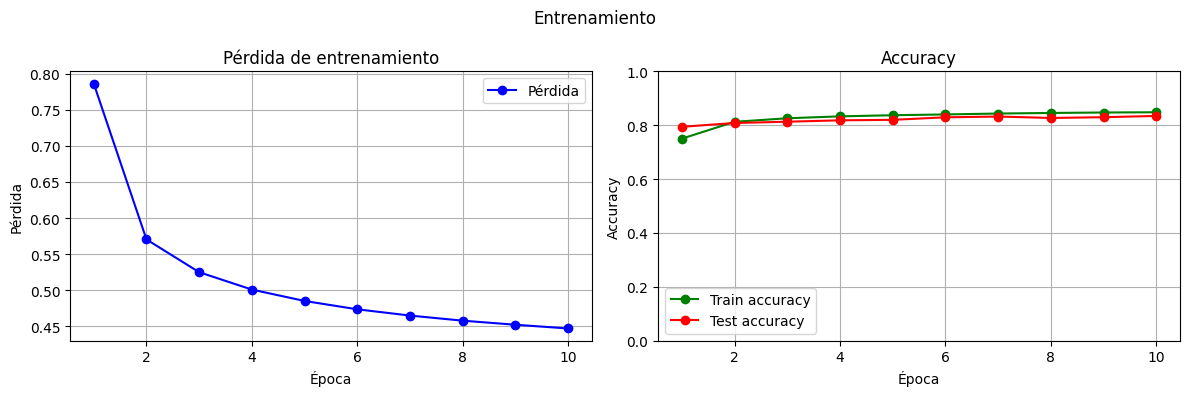

In [18]:
train_dataloader, test_dataloader = load_data_fashion_mnist(256);

metrics = train(net, train_dataloader, test_dataloader, loss, 10, trainer)
plot_metrics(metrics)

**Pregunta de análisis:**

Observando las curvas:
1. ¿El modelo converge? ¿Cómo se ve eso en el gráfico de pérdida?
2. ¿Hay diferencia entre el train accuracy y el test accuracy? ¿Qué indicaría si esa diferencia fuera muy grande?}

Sí, el modelo converge cuando la curva de pérdida (Loss) deja de descender drásticamente y comienza a estabilizarse en un valor mínimo constante.

Generalmente existe una pequeña diferencia donde el Train Accuracy es ligeramente superior al Test Accuracy. Si la diferencia es muy grande: Indica que el modelo ha caído en Overfitting (sobreajuste). Esto significa que el modelo se volvió tan experto en "memorizar" los detalles y el ruido de las imágenes de entrenamiento que perdió su capacidad de reconocer imágenes nuevas (de prueba).


---
## Fin del Laboratorio 1b

Completaste la primera parte del laboratorio de entrenamiento. En el Laboratorio 1c vas a construir un denoising autoencoder.